<a href="https://colab.research.google.com/github/ssrid111/Astryx/blob/main/netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 MB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.4.1-py2.py3-none-any.whl size=311285398 sha256=5c8729ca009b0e97acb301ef3792034c164661a55d62555dda8f76c3b8bc2273
  Stored in directory: /root/.cache/pip/wheels/0d/77/a3/ff2f74cc9ab41f8f594dabf0579c2a7c6de920d584206e0834
Successfully built pyspark


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.streaming import StreamingQuery

spark = SparkSession.builder \
        .appName("Stream Analysis") \
        .master("local[*]") \
        .getOrCreate()

In [ ]:
import os

for dirname, _, filenames in os.walk('/content/drive/MyDrive/netflix_titles.csv'):
    for filename in filenames:
        print(os.path.join('/content/drive/MyDrive','/content/drive/MyDrive/netflix_titles.csv'))

In [ ]:
spark = SparkSession.builder.appName("NetflixDataStreamAnalysis").getOrCreate()

In [ ]:
schema = "show_id INT, type STRING, title STRING, director STRING, cast STRING, country STRING, date_added STRING, release_year INT, rating STRING, duration STRING, listed_in STRING, description STRING"

In [ ]:
streaming_df = spark.readStream.format("socket").option("host", "localhost").option("port", 9999).load()


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [ ]:
df.duplicated().head()

0    False
1    False
2    False
3    False
4    False
dtype: bool

In [ ]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [ ]:
df.isna()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

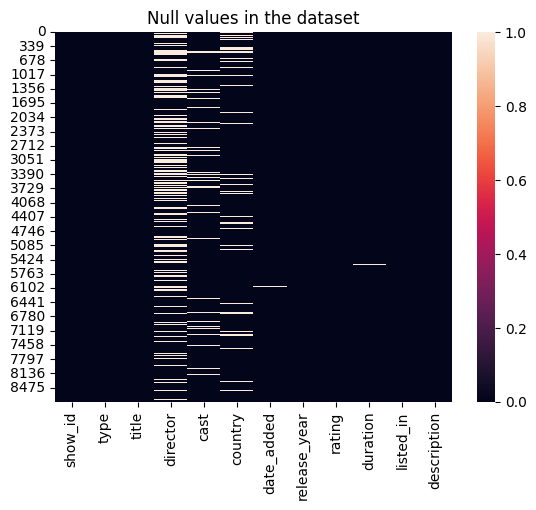

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.isna())
plt.title("Null values in the dataset")
plt.show()

In [ ]:
df.fillna("-",inplace=True)

In [ ]:
df.isna().head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

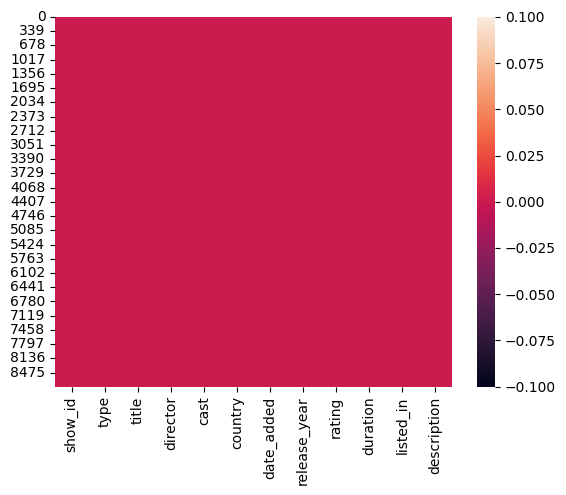

In [ ]:
sns.heatmap(df.isna(),color='red')
plt.show();

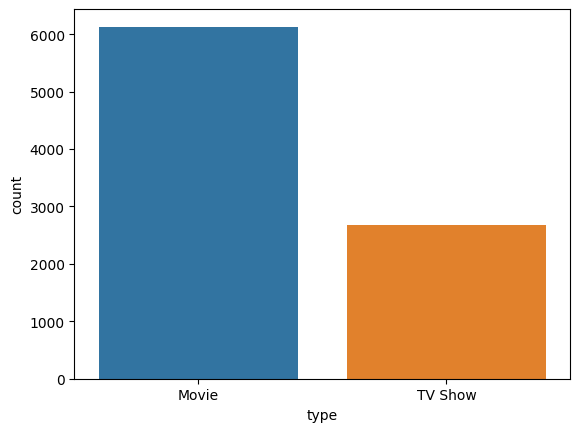

In [ ]:
sns.countplot(x='type',data=df)
plt.show()

In [ ]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,-,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."


In [ ]:
yeardata=df.groupby('release_year')
yeardata

In [ ]:
yeardata2020=yeardata.get_group(2020)
yeardata2020.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,-,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",-,-,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
17,s18,TV Show,Falsa identidad,-,"Luis Ernesto Franco, Camila Sodi, Sergio Goyri...",Mexico,"September 22, 2021",2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ...",Strangers Diego and Isabel flee their home in ...
32,s33,TV Show,Sex Education,-,"Asa Butterfield, Gillian Anderson, Ncuti Gatwa...",United Kingdom,"September 17, 2021",2020,TV-MA,3 Seasons,"British TV Shows, International TV Shows, TV C...",Insecure Otis has all the answers when it come...
34,s35,TV Show,Tayo and Little Wizards,-,"Dami Lee, Jason Lee, Bommie Catherine Han, Jen...",-,"September 17, 2021",2020,TV-Y7,1 Season,Kids' TV,Tayo speeds into an adventure when his friends...


In [ ]:
yeardata2020['type'].value_counts()

Movie      517
TV Show    436
Name: type, dtype: int64

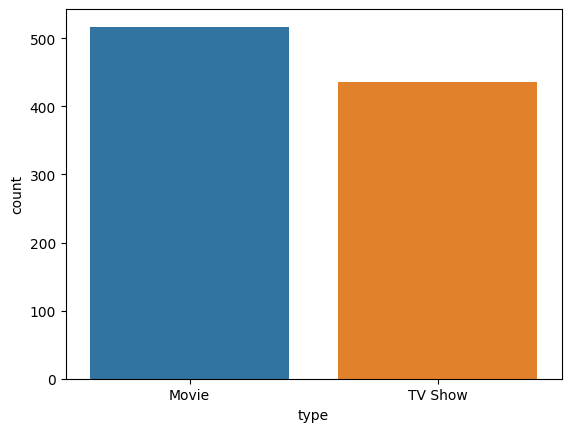

In [ ]:
sns.countplot(x='type',data=yeardata2020sns.countplot(x='release_year',data=dfabove10,hue='type',palette='Accent')sns.countplot(x='release_year',data=dfabove10,hue='type',palette='Accent'))
plt.show()

In [ ]:
dfabove11=df[df['release_year'] > 2011]

In [ ]:
dfabove11

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,-,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,-,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",-,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,-,-,-,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,-,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...
8800,s8801,TV Show,Zindagi Gulzar Hai,-,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8803,s8804,TV Show,Zombie Dumb,-,-,-,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."


<Axes: xlabel='release_year', ylabel='count'>

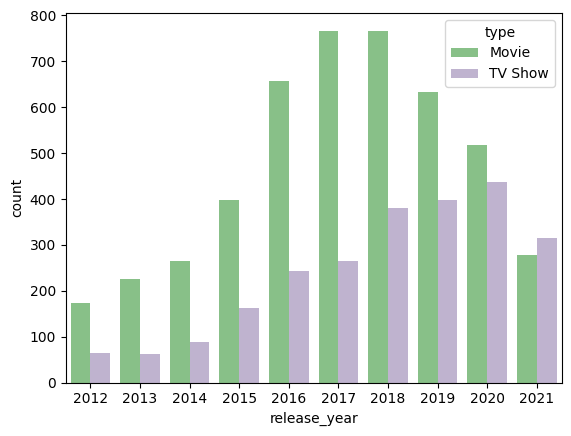

In [ ]:
sns.countplot(x='release_year',data=dfabove11,hue='type',palette='Accent')

In [ ]:
typegrp=df.groupby(['type'])

In [ ]:
movies=typegrp.get_group('Movie')

In [ ]:
moviesabove11=movies[movies['release_year'] > 2011]

In [ ]:
moviesabove11['release_year'].value_counts()

2017    767
2018    767
2016    658
2019    633
2020    517
2015    398
2021    277
2014    264
2013    225
2012    173
Name: release_year, dtype: int64

In [ ]:
moviesabove11.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,-,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",-,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",-,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...


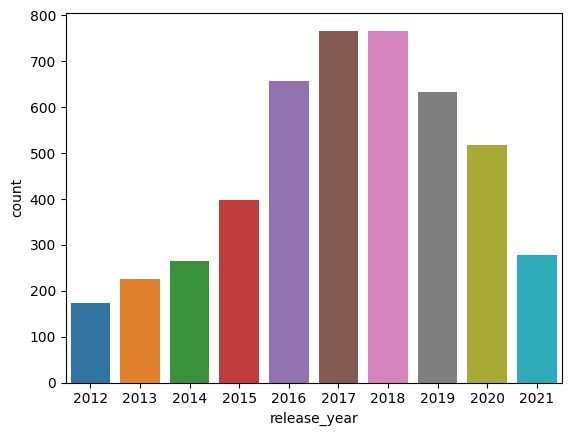

In [ ]:
sns.countplot(x='release_year',data=moviesabove11)
plt.show()

In [ ]:
fmovies=moviesabove11.filter(['release_year','country','duration'])

In [ ]:
englishmovies=fmovies.groupby('country').get_group('United States')

In [ ]:
englishmovies

,release_year,country,duration
0,2020,United States,90 min
9,2021,United States,104 min
28,2013,United States,97 min
81,2021,United States,106 min
96,2018,United States,97 min
...,...,...,...
8754,2016,United States,109 min
8756,2019,United States,97 min
8760,2013,United States,93 min
8782,2016,United States,88 min


In [ ]:
englishmovies.release_year.value_counts()

2017    284
2018    246
2019    217
2016    210
2020    177
2015    113
2014     76
2013     71
2012     59
2021     49
Name: release_year, dtype: int64

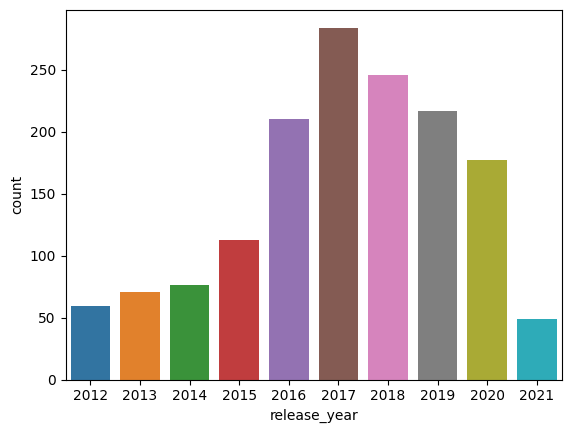

In [ ]:
sns.countplot(x='release_year',data=englishmovies)
plt.show()

In [ ]:
englishmovies.duration.value_counts()

90 min     60
97 min     54
92 min     48
86 min     44
93 min     44
           ..
10 min      1
142 min     1
3 min       1
49 min      1
152 min     1
Name: duration, Length: 131, dtype: int64

In [ ]:
englishmovies[englishmovies['duration']=='142 min']

,release_year,country,duration
3759,2019,United States,142 min


In [ ]:
englishmovies[englishmovies['release_year']==2017]

,release_year,country,duration
171,2017,United States,120 min
445,2017,United States,94 min
446,2017,United States,105 min
491,2017,United States,97 min
866,2017,United States,92 min
...,...,...,...
8707,2017,United States,38 min
8716,2017,United States,84 min
8730,2017,United States,86 min
8734,2017,United States,78 min


In [ ]:
englishmovies[englishmovies['release_year']==2020]

,release_year,country,duration
0,2020,United States,90 min
227,2020,United States,95 min
229,2020,United States,90 min
433,2020,United States,102 min
473,2020,United States,93 min
...,...,...,...
3009,2020,United States,121 min
3027,2020,United States,66 min
3041,2020,United States,97 min
7594,2020,United States,89 min


In [ ]:
englishmovies[englishmovies['release_year']==2017].value_counts()

release_year  country        duration
2017          United States  92 min      14
                             89 min      11
                             90 min      11
                             95 min      10
                             66 min       9
                                         ..
                             46 min       1
                             51 min       1
                             60 min       1
                             64 min       1
                             55 min       1
Length: 82, dtype: int64

In [ ]:
moviesabove11['listed_in'].value_counts()

Documentaries                                           337
Stand-Up Comedy                                         298
Dramas, International Movies                            280
Dramas, Independent Movies, International Movies        217
Comedies, Dramas, International Movies                  200
                                                       ... 
Action & Adventure, Romantic Movies                       1
Sports Movies                                             1
Sci-Fi & Fantasy                                          1
Horror Movies, International Movies, Romantic Movies      1
Comedies, Cult Movies, Independent Movies                 1
Name: listed_in, Length: 216, dtype: int64

In [ ]:
moviesdoc=moviesabove11.groupby('listed_in').get_group('Documentaries')
moviesdoc

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,-,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
45,s46,Movie,My Heroes Were Cowboys,Tyler Greco,-,-,"September 16, 2021",2021,PG,23 min,Documentaries,Robin Wiltshire's painful childhood was rescue...
117,s118,Movie,Final Account,Luke Holland,-,"United Kingdom, United States","September 2, 2021",2021,PG-13,94 min,Documentaries,This documentary stitches together never-befor...
221,s222,Movie,"Bob Ross: Happy Accidents, Betrayal & Greed",Joshua Rofé,Bob Ross,-,"August 25, 2021",2021,TV-14,93 min,Documentaries,Bob Ross brought joy to millions as the world’...
304,s305,Movie,Lady Boss: The Jackie Collins Story,Laura Fairrie,Jackie Collins,United Kingdom,"August 5, 2021",2021,TV-14,97 min,Documentaries,"""Queen of Sleaze"" or feminist pioneer? Powerho..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8701,s8702,Movie,Water & Power: A California Heist,Marina Zenovich,-,United States,"February 1, 2018",2017,PG,78 min,Documentaries,California residents and farmers face powerful...
8702,s8703,Movie,Waterschool,Tiffanie Hsu,-,"United States, Brazil, India, Uganda, China","July 25, 2018",2018,TV-G,68 min,Documentaries,"Six young women, who each live near one of Ear..."
8723,s8724,Movie,What Makes a Psychopath?,Rebecca Harrison,-,United Kingdom,"February 1, 2019",2017,TV-14,52 min,Documentaries,This wide-ranging documentary examines the beh...
8737,s8738,Movie,Why Are We Getting So Fat?,"Milla Harrison-Hansley, Alicky Sussman",Giles Yeo,United Kingdom,"February 1, 2019",2016,TV-14,50 min,Documentaries,A Cambridge geneticist dispels misconceptions ...


In [ ]:
turkey=moviesdoc[moviesdoc['country']=='Turkey']

In [ ]:
turkey

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [ ]:
turkey[turkey['release_year']==2021]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [ ]:
moviesdoc[moviesdoc['country']=='Turkey']['title']

Series([], Name: title, dtype: object)

In [ ]:
df[df['title']=='Dark']

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2327,s2328,TV Show,Dark,-,"Louis Hofmann, Oliver Masucci, Jördis Triebel,...","Germany, United States","June 27, 2020",2020,TV-MA,3 Seasons,"Crime TV Shows, International TV Shows, TV Dramas",A missing child sets four families on a franti...


In [ ]:
df[df['title']=='Dark'][['release_year','type','description']]

,release_year,type,description
2327,2020,TV Show,A missing child sets four families on a franti...


In [ ]:
df[df['title']=='Dark']['description']

2327    A missing child sets four families on a franti...
Name: description, dtype: object

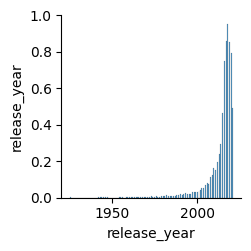

In [ ]:
sns.pairplot(df)
plt.show()

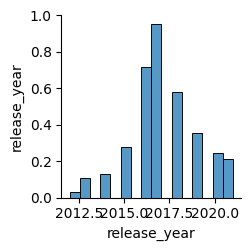

In [ ]:
sns.pairplot(moviesdoc)

In [ ]:
df=df.dropna()
df.shape

(8807, 12)

In [ ]:
netflix_overall=pd.read_csv("/content/drive/MyDrive/netflix_titles.csv")
netflix_overall.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
netflix_overall.count()

show_id         8807
type            8807
title           8807
director        6173
cast            7982
country         7976
date_added      8797
release_year    8807
rating          8803
duration        8804
listed_in       8807
description     8807
dtype: int64

In [ ]:
netflix_shows=netflix_overall[netflix_overall['type']=='TV Show']

In [ ]:
netflix_movies=netflix_overall[netflix_overall['type']=='Movie']

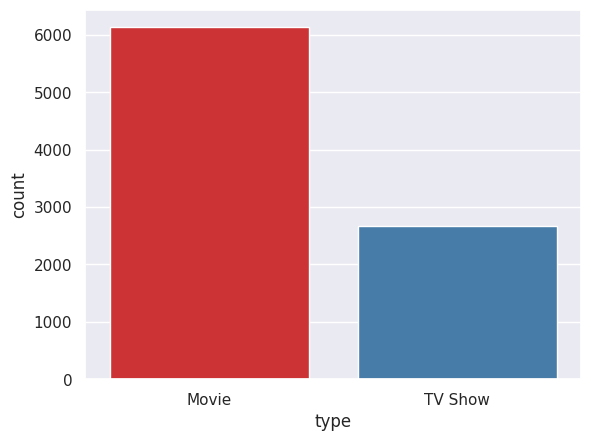

In [ ]:
sns.set(style="darkgrid")
ax = sns.countplot(x="type", data=netflix_overall, palette="Set1")

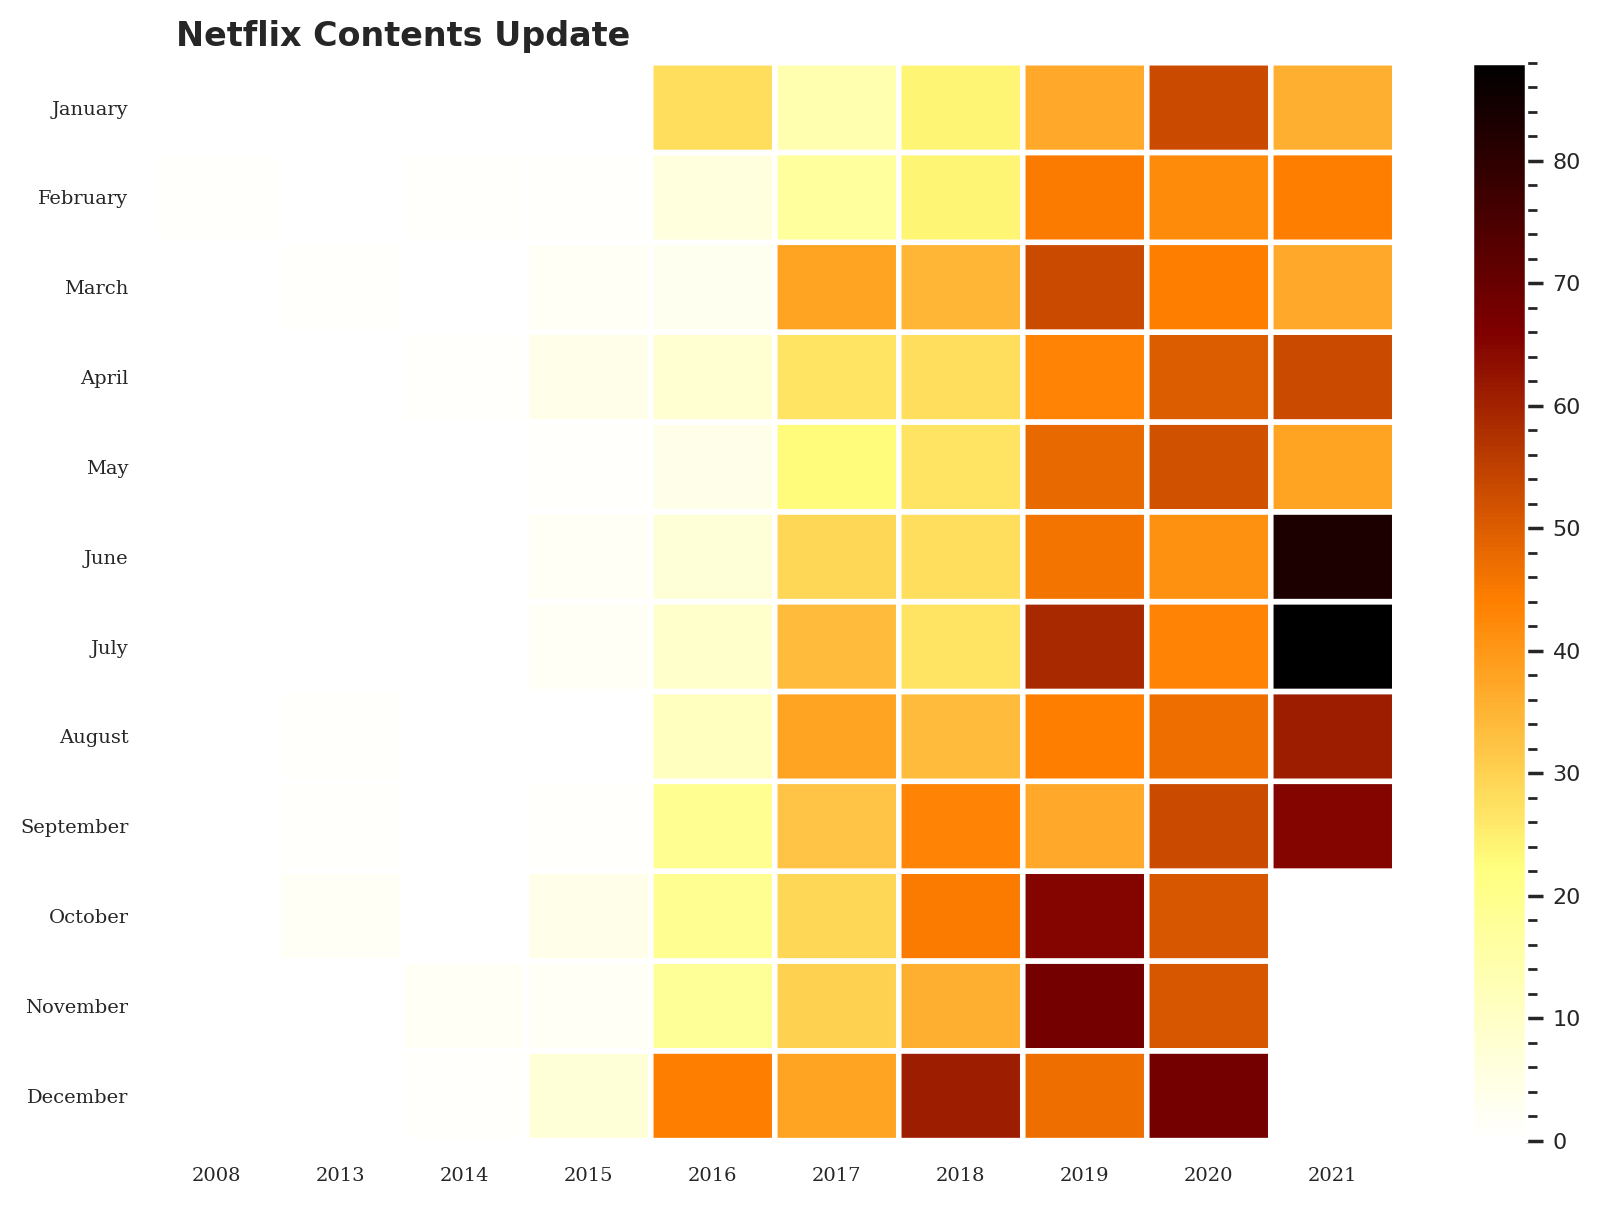

In [ ]:
netflix_date = netflix_shows[['date_added']].dropna()
netflix_date['year'] = netflix_date['date_added'].apply(lambda x : x.split(', ')[-1])
netflix_date['month'] = netflix_date['date_added'].apply(lambda x : x.lstrip().split(' ')[0])

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'][::-1]
df = netflix_date.groupby('year')['month'].value_counts().unstack().fillna(0)[month_order].T
plt.figure(figsize=(10, 7), dpi=200)
plt.pcolor(df, cmap='afmhot_r', edgecolors='white', linewidths=2) # heatmap
plt.xticks(np.arange(0.5, len(df.columns), 1), df.columns, fontsize=7, fontfamily='serif')
plt.yticks(np.arange(0.5, len(df.index), 1), df.index, fontsize=7, fontfamily='serif')

plt.title('Netflix Contents Update', fontsize=12, fontfamily='calibri', fontweight='bold', position=(0.20, 1.0+0.02))
cbar = plt.colorbar()

cbar.ax.tick_params(labelsize=8)
cbar.ax.minorticks_on()
plt.show()

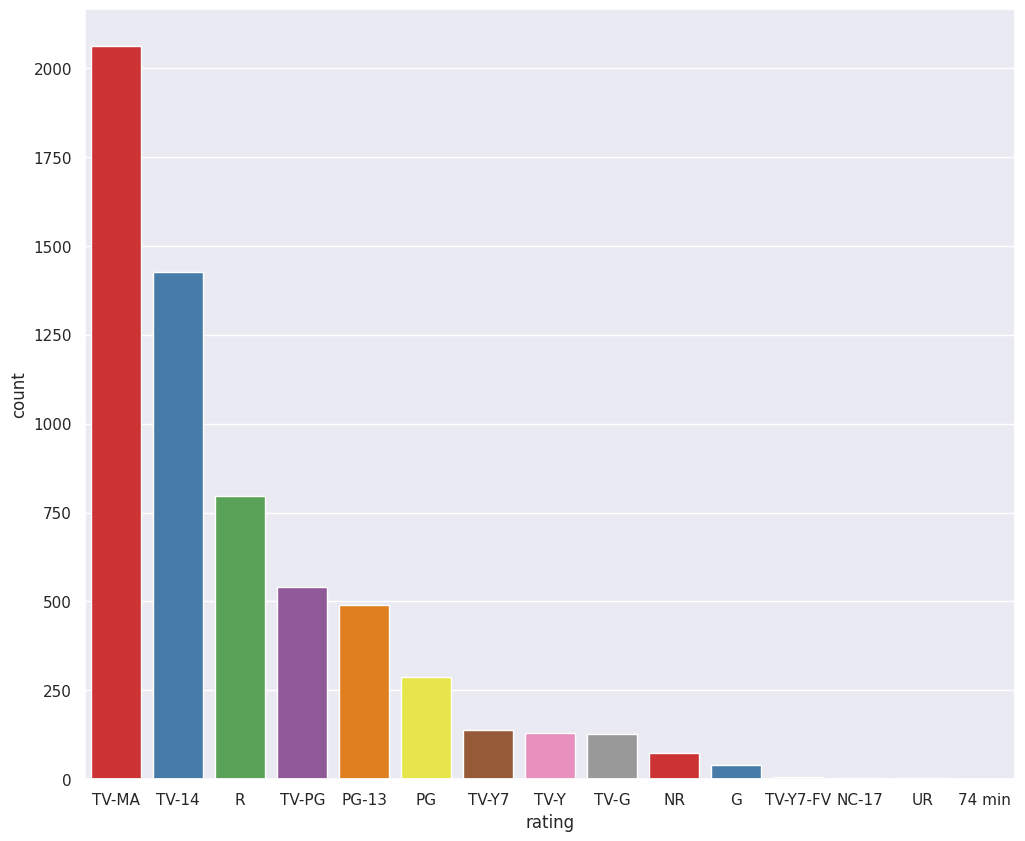

In [ ]:
plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(x="rating", data=netflix_movies, palette="Set1", order=netflix_movies['rating'].value_counts().index[0:15])

In [ ]:
import plotly.express as px
data = dict(
    number=[1063,619,135,60,44,41,40,40,38,35],
    country=["United States", "India", "United Kingdom", "Canada", "Spain",'Turkey','Philippines','France','South Korea','Australia'])
fig = px.funnel(data, x='country', y='number')
fig.show()

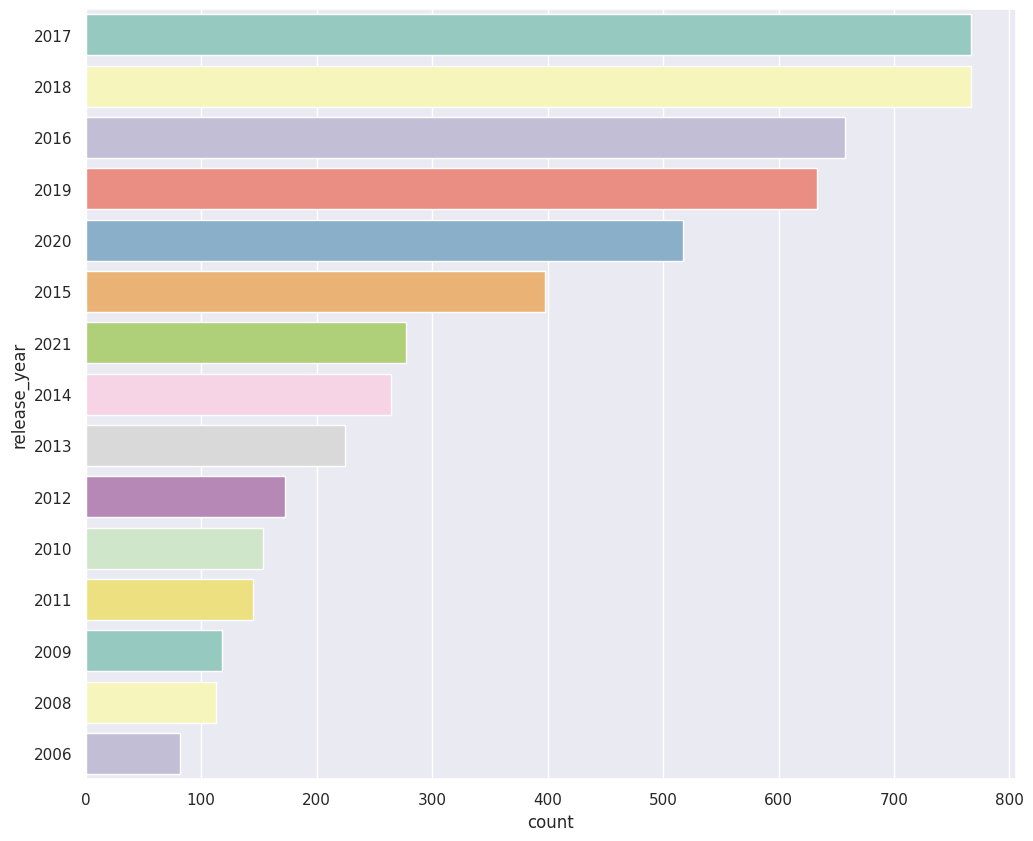

In [ ]:
plt.figure(figsize=(12,10))
sns.set(style="darkgrid")
ax = sns.countplot(y="release_year", data=netflix_movies, palette="Set3", order=netflix_movies['release_year'].value_counts().index[0:15])

In [ ]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

In [ ]:
schema = StructType([
    StructField("show_id", IntegerType()),
    StructField("type", StringType()),
    StructField("title", StringType()),
    StructField("director", StringType()),
    StructField("cast", StringType()),
    StructField("country", StringType()),
    StructField("date_added", StringType()),
    StructField("release_year", IntegerType()),
    StructField("rating", StringType()),
    StructField("duration", StringType()),
    StructField("listed_in", StringType()),
    StructField("description", StringType())
])


In [ ]:
streaming_df = spark.readStream.format("csv") \
    .option("header", True) \
    .schema(schema) \
    .csv("/content/drive/MyDrive/netflix_titles.csv")

In [ ]:
show_count_by_type = streaming_df.groupBy("type").count()

In [ ]:
query = show_count_by_type.writeStream.outputMode("complete").format("console").start()

In [ ]:
englishmovies[englishmovies['release_year']==2017]

,release_year,country,duration
171,2017,United States,120 min
445,2017,United States,94 min
446,2017,United States,105 min
491,2017,United States,97 min
866,2017,United States,92 min
...,...,...,...
8707,2017,United States,38 min
8716,2017,United States,84 min
8730,2017,United States,86 min
8734,2017,United States,78 min
